# Supplementary Notebook 20: Empirical FDR Calibration & Power Analysis

- **License:** [Creative Commons Attribution-NonCommercial 4.0 International License](https://creativecommons.org/licenses/by-nc/4.0/)
- **Version:** 0.3
- **Date:** 2026-03-18

## Overview

This notebook evaluates how well ProteoForge, COPF, and PeCorA control false discoveries and recover true signal. The analysis is organized in two parts:

**Part A — Null Calibration** (K=50 independent null datasets, no true proteoforms)

Every rejection is false by construction, giving direct empirical calibration of raw p-values, peptide-level FDR, protein-level FPR, and proteoform grouping FPR.

| Part | Level | Question |
|------|-------|----------|
| 1 | Raw p-values | Are p-values Uniform(0,1) under the null? |
| 2 | Peptide (identification) | Does empirical FPR track the nominal threshold α? |
| 3 | Protein | How often is a null protein flagged as significant? |
| 4 | Grouping (proteoform) | How often are proteoforms predicted when none exist? |

**Part B — Non-Null FDR-Power Trade-off** (2-peptide perturbation scenario)

Using one simulation and one benchmark dataset that contain real proteoform signal, we measure whether FDR stays calibrated when true positives are present and how much power each method achieves at a given false-discovery cost.

| Part | Level | Question |
|------|-------|----------|
| 5 | Peptide (identification) | Empirical FDR vs α, and power vs FDR |
| 6 | Protein (grouping) | Same at the proteoform grouping level |

**Appendix** — Correction strategy comparison for ProteoForge under the null.

## Companion Scripts

- `Revisions/logic/python/simulation/fdr_calibration/generate_null_data.py` — builds shared null datasets.
- `Revisions/logic/r/simulation/fdr_calibration/run_r_methods.R` — runs COPF & PeCorA on the same null inputs.


In [1]:
import os, sys, time, warnings
import multiprocessing as mp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as sp_stats
import pyarrow.feather as pf_io

# Resolve project root (3 levels up from this notebook)
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..', '..', '..'))
if not os.path.isfile(os.path.join(PROJECT_ROOT, 'requirements.txt')):
    PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), '..', '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

def project_relative_label(path, root=PROJECT_ROOT):
    rel = os.path.relpath(path, root)
    name = os.path.basename(root.rstrip(os.sep))
    return name if rel == '.' else os.path.join(name, rel)

from src import utils
from Simulation import sims
from ProteoForge import weight, model, disluster, correct

print(f"Project root: {project_relative_label(PROJECT_ROOT)}")
print("Libraries loaded successfully.")

Project root: Analysis_with_ProteoForge
Libraries loaded successfully.


In [2]:
# ── Visual identity ────────────────────────────────────────────────
METHOD_COLORS = {
    'ProteoForge': '#e54f2a',
    'PeCorA':      '#fca311',
    'COPF':        '#139593',
}
RAW_COLOR  = '#222222'
DIAG_COLOR = '#999999'

CORR_COLORS = {
    'Two-step (Bonf-BH)':  '#4477AA',
    'Protein-only (Bonf)': '#66CCEE',
    'Protein-only (BH)':   '#228833',
    'Global (BH)':         '#CCBB44',
    'Global (Bonf)':       '#EE6677',
}

sns.set_theme(style='white', context='paper', font_scale=1,
              rc={'figure.figsize': (6, 4), 'font.family': 'sans-serif',
                  'font.sans-serif': ['Arial']})
figure_dpi = 300

# ── Paths ─────────────────────────────────────────────────────────
notebook_name = 'FDRCalibration'
output_path = os.path.join(PROJECT_ROOT, 'Revisions', 'outputs', 'simulation', 'fdr_calibration')
figure_path = os.path.join(output_path, 'figures')
os.makedirs(output_path, exist_ok=True)
os.makedirs(os.path.join(figure_path, 'pdf'), exist_ok=True)

# ── Helpers ───────────────────────────────────────────────────────
def save_fig(fig, name):
    for ext, subdir in [('png', '.'), ('pdf', 'pdf')]:
        out = os.path.join(figure_path, subdir, f'{name}.{ext}')
        os.makedirs(os.path.dirname(out), exist_ok=True)
        fig.savefig(out, dpi=figure_dpi, bbox_inches='tight')
    print(f"  Saved: {name}.png / .pdf")

print(f"Output folder: {project_relative_label(output_path)}")
print(f"Figure folder: {project_relative_label(figure_path)}")

Output folder: Analysis_with_ProteoForge/Revisions/outputs/simulation/fdr_calibration
Figure folder: Analysis_with_ProteoForge/Revisions/outputs/simulation/fdr_calibration/figures


---

## Simulation Parameters

The null generating process has **no condition × peptide interaction** so raw p-values are $U(0,1)$ by construction. All rejections are therefore false positives, giving direct empirical calibration of the error-rate machinery.

See `generate_null_data.py` for the data generation details.

In [3]:
startTime = time.time()

# ── Null simulation parameters ────────────────────────────────────
K            = 50       # Publication scale (K=50 null runs)
base_seed    = 42
n_proteins   = 500
n_peptides   = (5, 50)
n_condition  = 3        # 1 control + 2 treatment
n_replicates = 10
model_to_use = 'rlm'
n_jobs       = min(mp.cpu_count() // 2, 16)

# ── Correction strategies ─────────────────────────────────────────
DEFAULT_CORRECTION = 'Two-step (Bonf-BH)'
correction_configs = {
    'Two-step (Bonf-BH)':  {'strategy': 'two-step',    'methods': ('bonferroni', 'fdr_bh')},
    'Protein-only (Bonf)': {'strategy': 'protein-only', 'methods': 'bonferroni'},
    'Protein-only (BH)':   {'strategy': 'protein-only', 'methods': 'fdr_bh'},
    'Global (BH)':         {'strategy': 'global',       'methods': 'fdr_bh'},
    'Global (Bonf)':       {'strategy': 'global',       'methods': 'bonferroni'},
}
corr_names = list(correction_configs.keys())

# ── Alpha grid ────────────────────────────────────────────────────
_log = list(utils.generate_thresholds(10.0, -15, 1, 0, 1, 0.1))
_mid = [round(v, 4) for v in np.arange(0.010, 0.105, 0.005).tolist()]
alpha_grid = sorted(set(_log + _mid))
alpha_grid = [a for a in alpha_grid if 0 < a <= 1.0]

print(f"K = {K} null runs | {n_proteins} proteins | {len(alpha_grid)} alpha points")
print(f"Default correction: {DEFAULT_CORRECTION}")
print(f"CPU cores: {n_jobs} / {mp.cpu_count()}")


K = 50 null runs | 500 proteins | 41 alpha points
Default correction: Two-step (Bonf-BH)
CPU cores: 16 / 32


---

## Pipeline Execution

`simulate_null_rawpvals` runs the ProteoForge pipeline (weight → RLM → cluster) on each null dataset, caching the raw p-values and cluster assignments to disk. `apply_correction` then layers different multiple-testing strategies on top.

In [4]:
def simulate_null_rawpvals(
        run_idx, base_seed, n_proteins, n_peptides, n_condition, n_replicates,
        model_to_use, n_jobs, verbose=True):
    """
    Load the canonical null dataset for run_idx and run the full ProteoForge
    pipeline: build_test_data -> weights -> RLM -> disluster.

    Data is loaded from pre-generated feather files produced by generate_null_data.py.
    This guarantees that ProteoForge, COPF, and PeCorA all operate on the same null
    draws, making cross-method FDR comparison valid.
    """
    t0 = time.time()
    seed = base_seed + run_idx
    np.random.seed(seed)

    # Load pre-generated null data shared with R methods
    input_path = os.path.join(
        output_path, 'null_input', f'null_run_{run_idx}_InputData.feather')
    if not os.path.exists(input_path):
        raise FileNotFoundError(
            f"Null input data not found: {project_relative_label(input_path)}\n"
            "Run generate_null_data.py first to generate shared null datasets.")
    raw_df = pd.read_feather(input_path)

    # Reconstruct condition_sample_map from data
    condition_sample_map = (
        raw_df[['Condition', 'Sample']].drop_duplicates()
        .groupby('Condition')['Sample'].apply(sorted).apply(list).to_dict())

    # Pivot to wide-format MultiIndex (Protein, Peptide) x Sample
    wide_data = raw_df.pivot_table(
        index=['Protein', 'Peptide'], columns='Sample', values='Intensity'
    ).rename_axis(None, axis=1)
    wide_data.index.names = ['Protein', 'Peptide']

    # Build test data
    test_data = sims.build_test_data(
        data=wide_data, condition_sample_map=condition_sample_map,
        perturbation_map={}, proteins_to_perturb=[], missing_data=None)
    test_data['pertCondition'] = test_data['pertCondition'].apply(
        lambda x: str(x.tolist()) if isinstance(x, np.ndarray) else str(x))
    test_data['pertShift'] = test_data['pertShift'].apply(
        lambda x: str(x.tolist()) if isinstance(x, np.ndarray) else str(x))

    # Weights
    weights_data = weight.generate_weights_data(
        test_data, sample_cols=['Sample'], log_intensity_col='log10Intensity',
        adj_intensity_col='adjIntensity', control_condition='control',
        condition_col='Condition', protein_col='Protein', peptide_col='Peptide',
        is_real_col='isReal', is_comp_miss_col='isCompMiss',
        sparse_imputed_val=1e-10, dense_imputed_val=0.75, verbose=False)
    test_data['Weight'] = (
        weights_data['W_Impute'] * 0.90 + weights_data['W_RevTechVar'] * 0.10)

    # Statistical model
    cur_model = model.LinearModel(
        data=test_data, protein_col='Protein', peptide_col='Peptide',
        cond_col='Condition', intensity_col='adjIntensity', weight_col='Weight')
    result_data = cur_model.run_analysis(
        model_type=model_to_use, correction_strategy='two-step',
        correction_methods=('bonferroni', 'fdr_bh'), n_jobs=n_jobs)
    result_data['has_comp_miss'] = (
        result_data.groupby(['Protein', 'PeptideID'])['isCompMiss'].transform('max'))

    result = (
        result_data[['Protein', 'PeptideID', 'pval', 'has_comp_miss']]
        .drop_duplicates(subset=['Protein', 'PeptideID'])
        .dropna(subset=['pval']).copy())
    result.insert(0, 'run', run_idx + 1)
    result['pertPFG'] = -1  # null: no protein has a true proteoform

    # Clustering
    clust_result = disluster.distance_and_cluster(
        data=result_data, protein_col='Protein', peptide_col='PeptideID',
        cond_col='Condition', quant_col='adjIntensity',
        clustering_params={
            'min_clusters': 1, 'distance_transform': 'corr',
            'clustering_method': 'hybrid_outlier_cut',
            'linkage_method': 'ward', 'distance_metric': 'euclidean'},
        n_jobs=n_jobs, verbose=False)
    clust_map = (
        clust_result[['Protein', 'PeptideID', 'cluster_label']]
        .drop_duplicates(subset=['Protein', 'PeptideID'])
        .rename(columns={'cluster_label': 'ClusterID'}))
    result = result.merge(clust_map, on=['Protein', 'PeptideID'], how='left')

    elapsed = time.time() - t0
    if verbose:
        n_comp = int(result['has_comp_miss'].sum())
        n_clust = result['ClusterID'].nunique()
        print(f"    Run {run_idx + 1:>2}/{K}: {len(result):,} tests "
              f"| {n_comp} complete-miss peps | {n_clust} clusters | {elapsed:.1f}s")
    return result


def apply_correction(pval_df, strategy, methods):
    """Apply a p-value correction strategy post-hoc to raw p-values."""
    if strategy == 'two-step':
        prot_m, glob_m = methods
        prt = pval_df.groupby('Protein')['pval'].transform(
            lambda x: correct.for_multiple_tests(x, correction_type=prot_m))
        return np.asarray(correct.for_multiple_tests(prt, correction_type=glob_m))
    elif strategy == 'global':
        return np.asarray(
            correct.for_multiple_tests(pval_df['pval'], correction_type=methods))
    elif strategy == 'protein-only':
        return np.asarray(
            pval_df.groupby('Protein')['pval'].transform(
                lambda x: correct.for_multiple_tests(x, correction_type=methods)))
    else:
        raise ValueError(f"Unknown correction strategy: {strategy!r}")


print("Functions defined: simulate_null_rawpvals, apply_correction")
print(f"Data source: shared null feathers in "
      f"{project_relative_label(os.path.join(output_path, 'null_input'))}")

Functions defined: simulate_null_rawpvals, apply_correction
Data source: shared null feathers in Analysis_with_ProteoForge/Revisions/outputs/simulation/fdr_calibration/null_input


In [5]:
warnings.filterwarnings('ignore')

# ── Run ProteoForge on each null dataset ──────────────────────────
raw_pval_store = {}
cond_name = 'Raw (no missingness)'
safe = 'Raw_no_missingness'
cache = os.path.join(output_path, f'rawpvals_full_{safe}_K{K}.feather')

if os.path.exists(cache):
    print(f"Loading cached: {os.path.basename(cache)}")
    raw_pval_store[cond_name] = pd.read_feather(cache)
else:
    print(f"Running ProteoForge null pipeline (K={K})...")
    runs = []
    for k in range(K):
        runs.append(simulate_null_rawpvals(
            run_idx=k, base_seed=base_seed, n_proteins=n_proteins,
            n_peptides=n_peptides, n_condition=n_condition,
            n_replicates=n_replicates, model_to_use=model_to_use,
            n_jobs=n_jobs, verbose=True))
    cond_df = pd.concat(runs, ignore_index=True)
    cond_df.to_feather(cache)
    print(f"Saved: {project_relative_label(cache)}")
    raw_pval_store[cond_name] = cond_df

total_tests = len(raw_pval_store[cond_name])
n_runs = raw_pval_store[cond_name]['run'].nunique()
print(f"\nTotal: {total_tests:,} raw p-values across {n_runs} null runs")
print(f"ClusterID available: {'ClusterID' in raw_pval_store[cond_name].columns}")

Running ProteoForge null pipeline (K=50)...
    Run  1/50: 5,650 tests | 0 complete-miss peps | 9 clusters | 7.7s
    Run  2/50: 5,911 tests | 0 complete-miss peps | 11 clusters | 8.1s
    Run  3/50: 5,449 tests | 0 complete-miss peps | 10 clusters | 7.6s
    Run  4/50: 5,914 tests | 0 complete-miss peps | 10 clusters | 8.0s
    Run  5/50: 5,633 tests | 0 complete-miss peps | 8 clusters | 7.9s
    Run  6/50: 6,001 tests | 0 complete-miss peps | 9 clusters | 8.3s
    Run  7/50: 5,411 tests | 0 complete-miss peps | 8 clusters | 7.4s
    Run  8/50: 5,478 tests | 0 complete-miss peps | 10 clusters | 7.7s
    Run  9/50: 5,466 tests | 0 complete-miss peps | 10 clusters | 7.3s
    Run 10/50: 5,702 tests | 0 complete-miss peps | 7 clusters | 7.8s
    Run 11/50: 5,678 tests | 0 complete-miss peps | 9 clusters | 7.9s
    Run 12/50: 5,454 tests | 0 complete-miss peps | 9 clusters | 7.7s
    Run 13/50: 5,645 tests | 0 complete-miss peps | 8 clusters | 8.0s
    Run 14/50: 5,623 tests | 0 complete-m

---

## Data Assembly

Apply correction strategies to ProteoForge's raw p-values and load the pre-computed COPF & PeCorA results from the R companion script.

In [6]:
# ── Apply corrections to PF raw p-values ──────────────────────────
all_parts = []
for corr_name, corr_cfg in correction_configs.items():
    pieces = []
    for rid, run_df in raw_pval_store[cond_name].groupby('run'):
        run_df = run_df.copy().reset_index(drop=True)
        run_df['adj_pval'] = apply_correction(
            run_df, corr_cfg['strategy'], corr_cfg['methods'])
        run_df.dropna(subset=['adj_pval'], inplace=True)
        pieces.append(run_df)
    combo = pd.concat(pieces, ignore_index=True)
    combo['correction'] = corr_name
    all_parts.append(combo)
all_df = pd.concat(all_parts, ignore_index=True)

# ── Pre-compute calibration curves ───────────────────────────────
alpha_arr = np.array(alpha_grid)
cal_curves = {}
for (corr, rid), grp in all_df.groupby(['correction', 'run']):
    adj = grp['adj_pval'].values
    n = len(adj)
    cal_curves[(corr, rid)] = np.array([(adj <= a).sum() / n for a in alpha_arr])

print(f"ProteoForge: {len(all_df):,} rows, {len(cal_curves)} calibration curves")

# ── Load COPF & PeCorA results ───────────────────────────────────
id_csv_path  = os.path.join(output_path, f'rmethod_id_fpr_K{K}.csv')
grp_csv_path = os.path.join(output_path, f'rmethod_grp_fpr_K{K}.csv')
for path in [id_csv_path, grp_csv_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"R-method CSV not found: {project_relative_label(path)}\n"
            "Run: Rscript Revisions/logic/r/simulation/fdr_calibration/run_r_methods.R")

rmethod_id  = pd.read_csv(id_csv_path)
rmethod_grp = pd.read_csv(grp_csv_path)

copf_runs, pec_runs = [], []
for k in range(K):
    copf_path = os.path.join(output_path, f'copf_null_run{k:02d}.feather')
    pec_path  = os.path.join(output_path, f'pecora_null_run{k:02d}.feather')
    if os.path.exists(copf_path):
        copf_runs.append(pd.read_feather(copf_path))
    if os.path.exists(pec_path):
        pec_runs.append(pd.read_feather(pec_path))

# Extract raw p-values for cross-method comparison
first_corr = corr_names[0]
pf_raw = all_df.loc[all_df['correction'] == first_corr, 'pval'].dropna().values
pec_raw_all = np.concatenate([df['pvalue'].dropna().values for df in pec_runs])
copf_raw_all = np.concatenate([
    df['proteoform_score_pval'].dropna().values for df in copf_runs])

print(f"COPF: {len(copf_runs)} runs | PeCorA: {len(pec_runs)} runs")
print(f"Raw p-values | PF: {len(pf_raw):,} | PeCorA: {len(pec_raw_all):,} | COPF: {len(copf_raw_all):,}")

ProteoForge: 1,418,850 rows, 250 calibration curves
COPF: 50 runs | PeCorA: 50 runs
Raw p-values | PF: 283,770 | PeCorA: 283,720 | COPF: 275,518


---

# Part A — Null Calibration

## Part 1 · Raw P-Value Calibration

**Question:** Under a pure null (no proteoforms), are raw p-values well-calibrated?

A well-calibrated null model produces raw p-values that are approximately Uniform(0,1). The histogram and Q–Q plot below test that assumption for all three methods.

  Saved: raw_pval_histogram.png / .pdf


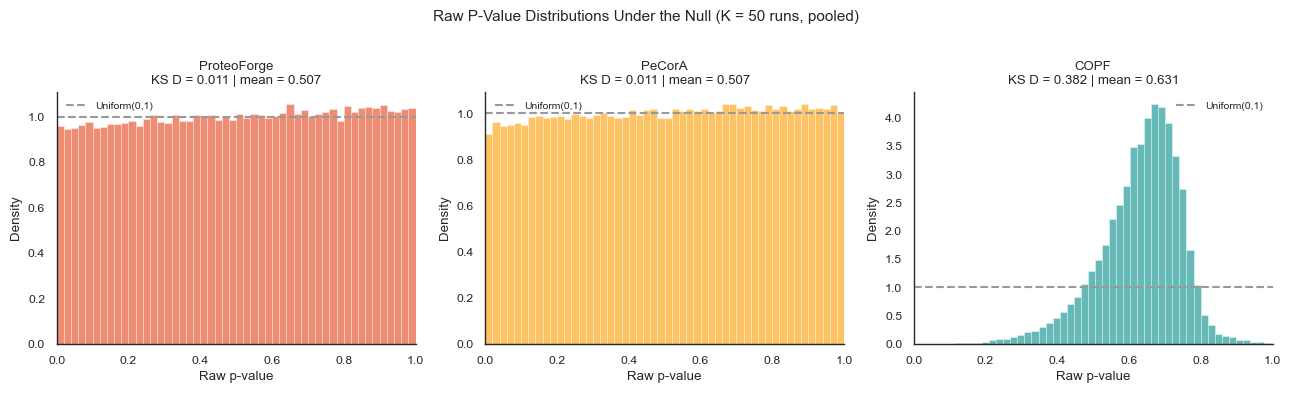

PF:     KS D=0.0110, mean=0.5072, % < 0.05 = 4.77%
PeCorA: KS D=0.0105, mean=0.5066, % < 0.05 = 4.68%
COPF:   KS D=0.3821, mean=0.6307, % < 0.05 = 0.01%


In [7]:
# ── Raw p-value distributions ──────────────────────────────────────
ks_D_pf,   ks_p_pf   = sp_stats.kstest(pf_raw, 'uniform')
ks_D_pec,  ks_p_pec  = sp_stats.kstest(pec_raw_all, 'uniform')
ks_D_copf, ks_p_copf = sp_stats.kstest(copf_raw_all, 'uniform')

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
n_bins = 50

for ax, (vals, name, mkey, ks_D) in zip(axes, [
    (pf_raw,       'ProteoForge', 'ProteoForge', ks_D_pf),
    (pec_raw_all,  'PeCorA',      'PeCorA',      ks_D_pec),
    (copf_raw_all, 'COPF',        'COPF',        ks_D_copf),
]):
    ax.hist(vals, bins=n_bins, density=True, color=METHOD_COLORS[mkey],
            alpha=0.65, edgecolor='white', linewidth=0.4)
    ax.axhline(1.0, color=DIAG_COLOR, ls='--', lw=1.5, label='Uniform(0,1)')
    ax.set_xlabel('Raw p-value')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}\nKS D = {ks_D:.3f} | mean = {vals.mean():.3f}', fontsize=9.5)
    ax.legend(fontsize=7.5, frameon=False)
    ax.set_xlim(0, 1)
    sns.despine(ax=ax)

fig.suptitle(f'Raw P-Value Distributions Under the Null (K = {K} runs, pooled)',
             fontsize=11, y=1.02)
fig.tight_layout()
save_fig(fig, 'raw_pval_histogram')
plt.show()

print(f"PF:     KS D={ks_D_pf:.4f}, mean={pf_raw.mean():.4f}, % < 0.05 = {(pf_raw < 0.05).mean()*100:.2f}%")
print(f"PeCorA: KS D={ks_D_pec:.4f}, mean={pec_raw_all.mean():.4f}, % < 0.05 = {(pec_raw_all < 0.05).mean()*100:.2f}%")
print(f"COPF:   KS D={ks_D_copf:.4f}, mean={copf_raw_all.mean():.4f}, % < 0.05 = {(copf_raw_all < 0.05).mean()*100:.2f}%")

**Histogram Insights:** ProteoForge (KS D = 0.011, mean = 0.507) and PeCorA (KS D = 0.011, mean = 0.507) both produce near-uniform null p-value distributions, confirming well-specified statistical models. COPF shows a pronounced right-skew (KS D = 0.382, mean = 0.631) with essentially no p-values below 0.05 (0.01% of tests) — its proteoform score is constructed as a summary statistic rather than a conventional hypothesis-test p-value, making its raw distribution non-uniform by design.

### Q–Q Plot

Points on the identity line indicate close agreement with Uniform(0,1). Curves below the line indicate conservative behaviour; curves above indicate anti-conservative behaviour and inflated type I error.


  Saved: qq_uniform.png / .pdf


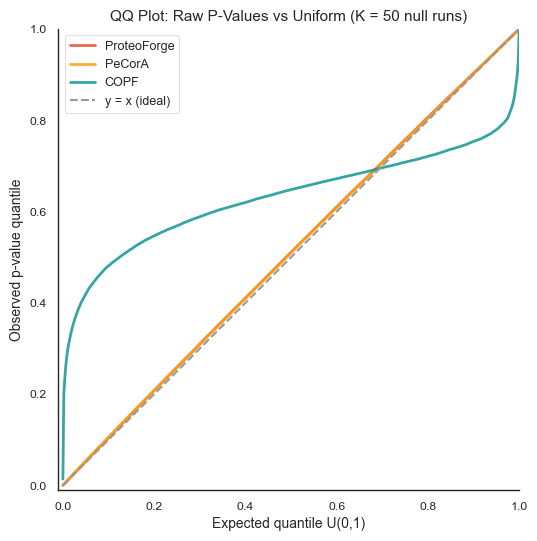

In [8]:
n_pts = 500

fig, ax = plt.subplots(figsize=(5.5, 5.5))
for name, raw_vals, mkey in [
    ('ProteoForge', pf_raw,       'ProteoForge'),
    ('PeCorA',      pec_raw_all,  'PeCorA'),
    ('COPF',        copf_raw_all, 'COPF'),
]:
    obs = np.sort(raw_vals)
    n = len(obs)
    expected = np.linspace(1 / n, 1 - 1 / n, n)
    common_x = np.linspace(0, 1, n_pts)
    obs_interp = np.interp(common_x, expected, obs)
    ax.plot(common_x, obs_interp, color=METHOD_COLORS[mkey],
            linewidth=2.0, label=name, alpha=0.85)

ax.plot([0, 1], [0, 1], '--', color=DIAG_COLOR, linewidth=1.5, label='y = x (ideal)')
ax.set_xlim(-0.01, 1); ax.set_ylim(-0.01, 1); ax.set_aspect('equal')
ax.set_xlabel('Expected quantile U(0,1)', fontsize=10)
ax.set_ylabel('Observed p-value quantile', fontsize=10)
ax.set_title(f'QQ Plot: Raw P-Values vs Uniform (K = {K} null runs)', fontsize=11)
ax.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='#dddddd')
sns.despine(ax=ax)
fig.tight_layout()
save_fig(fig, 'qq_uniform')
plt.show()

**Q–Q Insights:** ProteoForge and PeCorA lie close to the identity line across the full quantile range, confirming approximate Uniform(0,1) null behaviour. COPF's curve falls well below the diagonal (conservative), consistent with its right-skewed histogram — observed p-values are systematically larger than expected uniform quantiles, meaning COPF's raw p-values strongly under-reject under the null.

---

## Part 2 · Peptide-Level FDR Calibration (Null)

**Question:** As the nominal threshold changes, how closely does the peptide-level null rejection rate follow the expected diagonal?

For each threshold α, the null rejection rate is
$$\text{FPR}(\alpha) = \frac{\#\{p \leq \alpha\}}{N_{\text{tests}}}$$

Under a pure null this is also the empirical FDR because every rejection is false.

  Saved: peptide_fdr_calibration.png / .pdf


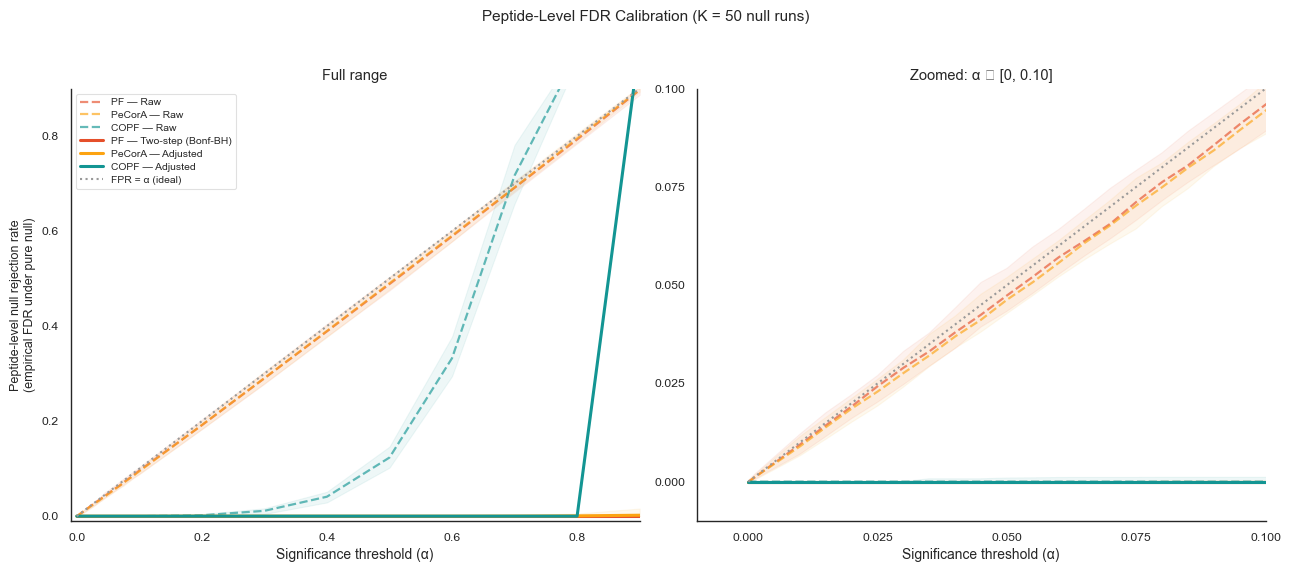


α = 0.01:
  PF Raw                        : median FPR = 0.0094
  PF Two-step (Bonf-BH)         : median FPR = 0.0000
  COPF Raw                      : median FPR = 0.0000
  COPF Adj                      : median FPR = 0.0000
  PeCorA Raw                    : median FPR = 0.0090
  PeCorA Adj                    : median FPR = 0.0000

α = 0.05:
  PF Raw                        : median FPR = 0.0474
  PF Two-step (Bonf-BH)         : median FPR = 0.0000
  COPF Raw                      : median FPR = 0.0000
  COPF Adj                      : median FPR = 0.0000
  PeCorA Raw                    : median FPR = 0.0463
  PeCorA Adj                    : median FPR = 0.0000

α = 0.10:
  PF Raw                        : median FPR = 0.0959
  PF Two-step (Bonf-BH)         : median FPR = 0.0000
  COPF Raw                      : median FPR = 0.0000
  COPF Adj                      : median FPR = 0.0000
  PeCorA Raw                    : median FPR = 0.0944
  PeCorA Adj                    : median FPR = 0.

In [9]:
plot_mask  = alpha_arr < 1.0
alpha_plot = alpha_arr[plot_mask]

# ── PF: raw & corrected calibration curves ────────────────────────
pf_raw_cal = {}
cond_df = raw_pval_store[cond_name]
for rid, run_df in cond_df.groupby('run'):
    pvals = run_df['pval'].dropna().values
    n = len(pvals)
    pf_raw_cal[rid] = np.array([(pvals <= a).sum() / n for a in alpha_arr])

run_ids_raw = sorted(pf_raw_cal.keys())
raw_mat = np.vstack([pf_raw_cal[rid][plot_mask] for rid in run_ids_raw])

default_runs = sorted(
    all_df.loc[all_df['correction'] == DEFAULT_CORRECTION, 'run'].unique())
default_mat = np.vstack([
    cal_curves[(DEFAULT_CORRECTION, rid)][plot_mask] for rid in default_runs])

# ── COPF: raw & adjusted calibration curves (from feather) ───────
copf_raw_cal, copf_adj_cal = {}, {}
for i, df_c in enumerate(copf_runs):
    rid = i + 1
    raw_pv = df_c['proteoform_score_pval'].dropna().values
    adj_pv = df_c['proteoform_score_pval_adj'].dropna().values
    copf_raw_cal[rid] = np.array([(raw_pv <= a).sum() / len(raw_pv) for a in alpha_arr])
    copf_adj_cal[rid] = np.array([(adj_pv <= a).sum() / len(adj_pv) for a in alpha_arr])

copf_raw_mat = np.vstack([copf_raw_cal[r][plot_mask] for r in sorted(copf_raw_cal)])
copf_adj_mat = np.vstack([copf_adj_cal[r][plot_mask] for r in sorted(copf_adj_cal)])

# ── PeCorA: raw & adjusted calibration curves (from feather) ─────
pec_raw_cal, pec_adj_cal = {}, {}
for i, df_p in enumerate(pec_runs):
    rid = i + 1
    raw_pv = df_p['pvalue'].dropna().values
    adj_pv = df_p['adj_pval'].dropna().values
    pec_raw_cal[rid] = np.array([(raw_pv <= a).sum() / len(raw_pv) for a in alpha_arr])
    pec_adj_cal[rid] = np.array([(adj_pv <= a).sum() / len(adj_pv) for a in alpha_arr])

pec_raw_mat = np.vstack([pec_raw_cal[r][plot_mask] for r in sorted(pec_raw_cal)])
pec_adj_mat = np.vstack([pec_adj_cal[r][plot_mask] for r in sorted(pec_adj_cal)])

# ── Two-panel figure ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1, 1]})

curves = [
    # (label, matrix, color_key, linestyle, linewidth, alpha, zorder)
    ('PF — Raw',                       raw_mat,      'ProteoForge', '--', 1.6, 0.65, 6),
    ('PeCorA — Raw',                   pec_raw_mat,  'PeCorA',      '--', 1.6, 0.65, 6),
    ('COPF — Raw',                     copf_raw_mat, 'COPF',        '--', 1.6, 0.65, 6),
    (f'PF — {DEFAULT_CORRECTION}',     default_mat,  'ProteoForge', '-',  2.2, 1.0,  8),
    ('PeCorA — Adjusted',              pec_adj_mat,  'PeCorA',      '-',  2.2, 1.0,  8),
    ('COPF — Adjusted',                copf_adj_mat, 'COPF',        '-',  2.2, 1.0,  8),
]

for panel_idx, (xlim, title_sfx) in enumerate([
    (alpha_plot.max(), 'Full range'),
    (0.10, 'Zoomed: α ∈ [0, 0.10]'),
]):
    ax = axes[panel_idx]

    for label, mat, mkey, ls, lw, a, zo in curves:
        ax.plot(alpha_plot, np.median(mat, axis=0),
                color=METHOD_COLORS[mkey], linewidth=lw, linestyle=ls,
                label=label, zorder=zo, alpha=a)
        ax.fill_between(alpha_plot,
                        np.percentile(mat, 2.5, axis=0),
                        np.percentile(mat, 97.5, axis=0),
                        color=METHOD_COLORS[mkey], alpha=0.07, zorder=zo - 1)

    ax.plot([0, xlim], [0, xlim], ':', color=DIAG_COLOR, linewidth=1.5,
            label='FPR = α (ideal)', zorder=10)
    ax.set_xlim(-0.01, xlim); ax.set_ylim(-0.01, xlim)
    ax.set_xlabel('Significance threshold (α)', fontsize=10)
    ax.set_title(title_sfx, fontsize=10.5, pad=6)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
    sns.despine(ax=ax)
    if panel_idx == 0:
        ax.legend(fontsize=7.5, frameon=True, framealpha=0.9, edgecolor='#dddddd',
                  loc='upper left', handlelength=2.2, labelspacing=0.35, ncol=1)

axes[0].set_ylabel('Peptide-level null rejection rate\n(empirical FDR under pure null)', fontsize=9)
fig.suptitle(f'Peptide-Level FDR Calibration (K = {K} null runs)', fontsize=11, y=1.03)
fig.tight_layout()
save_fig(fig, 'peptide_fdr_calibration')
plt.show()

# Print summary at key thresholds
for a_check in [0.01, 0.05, 0.10]:
    idx = np.argmin(np.abs(alpha_plot - a_check))
    print(f"\nα = {a_check:.2f}:")
    for lbl, mat in [('PF Raw', raw_mat), (f'PF {DEFAULT_CORRECTION}', default_mat),
                     ('COPF Raw', copf_raw_mat), ('COPF Adj', copf_adj_mat),
                     ('PeCorA Raw', pec_raw_mat), ('PeCorA Adj', pec_adj_mat)]:
        print(f"  {lbl:30s}: median FPR = {np.median(mat[:, idx]):.4f}")

**Peptide FDR Insights:** Raw (uncorrected) p-values for ProteoForge and PeCorA closely track the diagonal across the full α range, confirming proper null calibration before any multiple-testing correction (PF raw median FPR = 0.047 at α = 0.05, PeCorA raw = 0.046 — both essentially at nominal). After applying their respective corrections (Two-step Bonf-BH for PF, adjusted p-values for PeCorA, built-in adjusted p-values for COPF), all three methods become strongly conservative — their null rejection rates fall to zero across the full α ∈ [0, 0.10] range in the zoomed panel. COPF is the most conservative of the three since its raw p-values already strongly under-reject.

---

## Part 3 · Protein-Level FPR (Null)

**Question:** When results are summarised at the protein level, how often does each method flag a null protein as significant?

A protein is called a false positive if **any** of its peptides is significant. Because all proteins are null, every such call is wrong.


  Saved: protein_level_fpr.png / .pdf


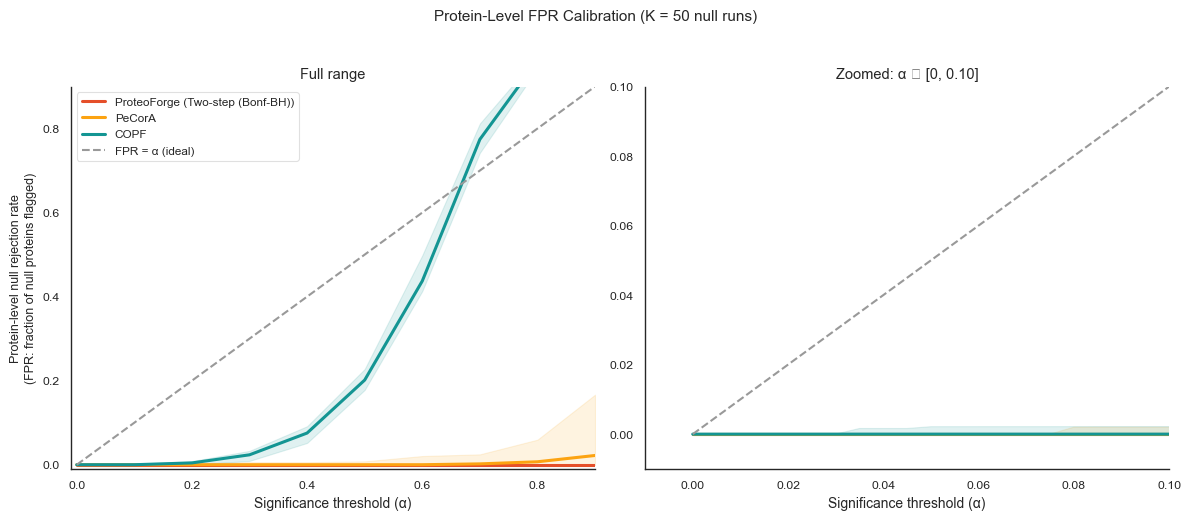

,0.01,0.05,0.10,0.20
Method,,,,
COPF,0.0000,0.0000,0.0000,0.0043
PeCorA,0.0000,0.0000,0.0000,0.0000
ProteoForge,0.0000,0.0000,0.0000,0.0000


Saved: Analysis_with_ProteoForge/Revisions/outputs/simulation/fdr_calibration/protein_fpr_summary_K50.csv


In [10]:
alpha_b = np.array(alpha_grid)
mask_b = alpha_b < 1.0
alpha_plot_b = alpha_b[mask_b]

# PF default: protein flagged if any peptide adj_pval < alpha
sub_default = all_df[all_df.correction == DEFAULT_CORRECTION]
pf_prot_curves = []
for _, run_sub in sub_default.groupby('run'):
    min_per_prot = run_sub.groupby('Protein')['adj_pval'].min().values
    curve = np.array([(min_per_prot < a).mean() for a in alpha_b[mask_b]])
    pf_prot_curves.append(curve)
pf_prot_mat = np.vstack(pf_prot_curves)

# PeCorA
pec_prot_curves = []
for df_p in pec_runs:
    min_pp = df_p.groupby('Protein')['adj_pval'].min().values
    curve = np.array([(min_pp < a).mean() for a in alpha_b[mask_b]])
    pec_prot_curves.append(curve)
pec_prot_mat = np.vstack(pec_prot_curves)

# COPF
copf_prot_curves = []
for df_c in copf_runs:
    prot_c = df_c.groupby('protein_id')['proteoform_score_pval'].first().dropna().values
    curve = np.array([(prot_c < a).mean() for a in alpha_b[mask_b]])
    copf_prot_curves.append(curve)
copf_prot_mat = np.vstack(copf_prot_curves)

# ── Two-panel figure ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for panel_idx, (xlim, title_sfx) in enumerate([
    (alpha_plot_b.max(), 'Full range'),
    (0.10, 'Zoomed: α ∈ [0, 0.10]'),
]):
    ax = axes[panel_idx]
    for name, mat, mkey in [
        (f'ProteoForge ({DEFAULT_CORRECTION})', pf_prot_mat, 'ProteoForge'),
        ('PeCorA', pec_prot_mat, 'PeCorA'),
        ('COPF', copf_prot_mat, 'COPF'),
    ]:
        ax.plot(alpha_plot_b, np.median(mat, axis=0),
                color=METHOD_COLORS[mkey], linewidth=2.2, label=name, zorder=6)
        ax.fill_between(alpha_plot_b,
                        np.percentile(mat, 2.5, axis=0),
                        np.percentile(mat, 97.5, axis=0),
                        color=METHOD_COLORS[mkey], alpha=0.13, zorder=5)
    ax.plot([0, xlim], [0, xlim], '--', color=DIAG_COLOR, linewidth=1.5,
            label='FPR = α (ideal)', zorder=10)
    ax.set_xlim(-0.01, xlim); ax.set_ylim(-0.01, xlim)
    ax.set_xlabel('Significance threshold (α)', fontsize=10)
    ax.set_title(title_sfx, fontsize=10.5, pad=6)
    sns.despine(ax=ax)
    if panel_idx == 0:
        ax.legend(fontsize=8.5, frameon=True, framealpha=0.9,
                  edgecolor='#dddddd', loc='upper left')

axes[0].set_ylabel('Protein-level null rejection rate\n(FPR: fraction of null proteins flagged)', fontsize=9)
fig.suptitle(f'Protein-Level FPR Calibration (K = {K} null runs)', fontsize=11, y=1.03)
fig.tight_layout()
save_fig(fig, 'protein_level_fpr')
plt.show()

# ── Summary table ─────────────────────────────────────────────────
canonical_alphas = [0.01, 0.05, 0.10, 0.20]
tbl_rows = []
for alpha in canonical_alphas:
    a_idx = np.argmin(np.abs(alpha_plot_b - alpha))
    for name, mat in [('ProteoForge', pf_prot_mat), ('PeCorA', pec_prot_mat), ('COPF', copf_prot_mat)]:
        fprs = mat[:, a_idx]
        tbl_rows.append({
            'Method': name, 'α': f'{alpha:.2f}',
            'FPR median': np.median(fprs),
            '95% CI': f'{np.percentile(fprs, 2.5):.4f} – {np.percentile(fprs, 97.5):.4f}',
        })
tbl_df = pd.DataFrame(tbl_rows)
display(tbl_df.pivot_table(index='Method', columns='α', values='FPR median', aggfunc='first')
        .rename_axis(None, axis=1)
        .style.set_caption(f'Protein-Level FPR at Canonical Thresholds (K = {K})')
        .format('{:.4f}'))

tbl_path = os.path.join(output_path, f'protein_fpr_summary_K{K}.csv')
tbl_df.to_csv(tbl_path, index=False)
print(f"Saved: {project_relative_label(tbl_path)}")

**Protein FPR Insights:** All three methods maintain strict protein-level FPR control across the practical threshold range. ProteoForge (Two-step Bonf-BH) and PeCorA (adjusted) show FPR = 0.000 at α ≤ 0.10. COPF is likewise near-zero throughout α ≤ 0.10, rising only in the mid-to-high range where its raw p-value distribution begins to produce rejections. The conservative cascade observed at the peptide level carries through uniformly to the protein level.

---

## Part 4 · Proteoform Grouping FPR (Null)

**Question:** After statistical identification, how often does each grouping method predict a proteoform when the truth contains none?

- **ProteoForge**: protein flagged if ≥ 2 significant peptides share a cluster.
- **COPF**: protein flagged if significant AND more than one cluster is present.
- **PeCorA** does not produce grouping output and is excluded.


  Saved: grouping_fpr.png / .pdf


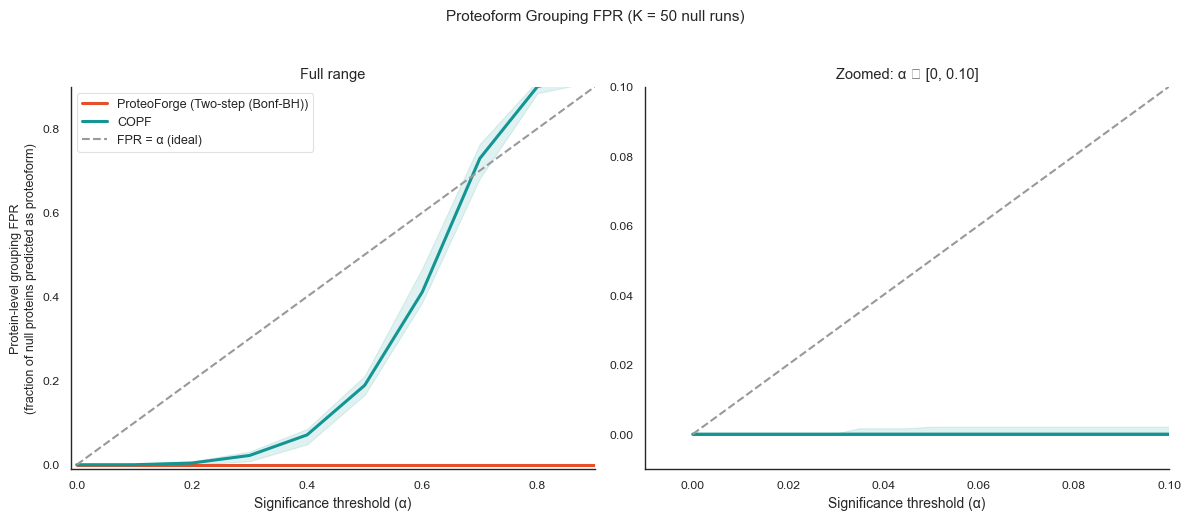

,0.01,0.05,0.10,0.20
Method,,,,
COPF,0.0000,0.0000,0.0000,0.0040
ProteoForge,0.0000,0.0000,0.0000,0.0000


Saved: Analysis_with_ProteoForge/Revisions/outputs/simulation/fdr_calibration/grouping_fpr_summary_K50.csv


In [11]:
# ── Compute PF grouping FPR curves ────────────────────────────────
alpha_arr_g = np.array(alpha_grid)
grp_curves = {}
for (corr, rid), grp in all_df.groupby(['correction', 'run']):
    grp = grp.copy().reset_index(drop=True)
    metrics = utils.grouping_performance_proteoforge(
        data=grp, thresholds=alpha_grid, pvalue_col='adj_pval',
        protein_col='Protein', cluster_col='ClusterID', perturbation_col='pertPFG')
    grp_curves[(corr, rid)] = metrics['FPR'].values

plot_mask_g = alpha_arr_g < 1.0
alpha_plot_g = alpha_arr_g[plot_mask_g]

# PF default
run_ids_pf = sorted(raw_pval_store[cond_name]['run'].unique())
pf_grp_mat = np.vstack([
    grp_curves[(DEFAULT_CORRECTION, rid)][plot_mask_g] for rid in run_ids_pf])

# COPF grouping
copf_grp_g = rmethod_grp[rmethod_grp.method == 'COPF']
copf_grp_alphas = sorted(copf_grp_g['alpha'].unique())
copf_grp_alpha_arr = np.array(copf_grp_alphas)
copf_grp_mask = copf_grp_alpha_arr < 1.0
copf_grp_pivot = (copf_grp_g.pivot(index='run', columns='alpha', values='fpr')
                  .values[:, copf_grp_mask])

# ── Two-panel figure ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for panel_idx, (xlim, title_sfx) in enumerate([
    (alpha_plot_g.max(), 'Full range'),
    (0.10, 'Zoomed: α ∈ [0, 0.10]'),
]):
    ax = axes[panel_idx]
    ax.plot(alpha_plot_g, np.median(pf_grp_mat, axis=0),
            color=METHOD_COLORS['ProteoForge'], linewidth=2.2,
            label=f'ProteoForge ({DEFAULT_CORRECTION})', zorder=6)
    ax.fill_between(alpha_plot_g,
                    np.percentile(pf_grp_mat, 2.5, axis=0),
                    np.percentile(pf_grp_mat, 97.5, axis=0),
                    color=METHOD_COLORS['ProteoForge'], alpha=0.13, zorder=5)
    ax.plot(copf_grp_alpha_arr[copf_grp_mask], np.median(copf_grp_pivot, axis=0),
            color=METHOD_COLORS['COPF'], linewidth=2.2, label='COPF', zorder=6)
    ax.fill_between(copf_grp_alpha_arr[copf_grp_mask],
                    np.percentile(copf_grp_pivot, 2.5, axis=0),
                    np.percentile(copf_grp_pivot, 97.5, axis=0),
                    color=METHOD_COLORS['COPF'], alpha=0.13, zorder=5)
    ax.plot([0, xlim], [0, xlim], '--', color=DIAG_COLOR, linewidth=1.5,
            label='FPR = α (ideal)', zorder=10)
    ax.set_xlim(-0.01, xlim); ax.set_ylim(-0.01, xlim)
    ax.set_xlabel('Significance threshold (α)', fontsize=10)
    ax.set_title(title_sfx, fontsize=10.5, pad=6)
    sns.despine(ax=ax)
    if panel_idx == 0:
        ax.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='#dddddd', loc='upper left')

axes[0].set_ylabel('Protein-level grouping FPR\n(fraction of null proteins predicted as proteoform)', fontsize=9)
fig.suptitle(f'Proteoform Grouping FPR (K = {K} null runs)', fontsize=11, y=1.03)
fig.tight_layout()
save_fig(fig, 'grouping_fpr')
plt.show()

# ── Summary table ─────────────────────────────────────────────────
grp_canonical = [0.01, 0.05, 0.10, 0.20]
grp_rows = []
for alpha in grp_canonical:
    a_idx = np.argmin(np.abs(alpha_arr_g - alpha))
    pf_vals = [grp_curves[(DEFAULT_CORRECTION, rid)][a_idx] for rid in run_ids_pf]
    grp_rows.append({'Method': 'ProteoForge', 'α': f'{alpha:.2f}',
                     'Grouping FPR median': np.median(pf_vals),
                     '95% CI': f'{np.percentile(pf_vals, 2.5):.4f} – {np.percentile(pf_vals, 97.5):.4f}'})
    copf_vals = rmethod_grp[
        (rmethod_grp.method == 'COPF') &
        (rmethod_grp.alpha.between(alpha - 0.001, alpha + 0.001))]['fpr'].values
    if len(copf_vals):
        grp_rows.append({'Method': 'COPF', 'α': f'{alpha:.2f}',
                         'Grouping FPR median': np.median(copf_vals),
                         '95% CI': f'{np.percentile(copf_vals, 2.5):.4f} – {np.percentile(copf_vals, 97.5):.4f}'})

grp_tbl = pd.DataFrame(grp_rows)
display(grp_tbl.pivot_table(index='Method', columns='α', values='Grouping FPR median', aggfunc='first')
        .rename_axis(None, axis=1)
        .style.set_caption(f'Proteoform Grouping FPR (K = {K} null runs)')
        .format('{:.4f}'))

grp_tbl_path = os.path.join(output_path, f'grouping_fpr_summary_K{K}.csv')
grp_tbl.to_csv(grp_tbl_path, index=False)
print(f"Saved: {project_relative_label(grp_tbl_path)}")

**Grouping FPR Insights:** Both ProteoForge and COPF achieve near-perfect grouping FPR control at all practical thresholds. ProteoForge achieves grouping FPR = 0.000 at α ≤ 0.20. COPF grouping FPR = 0.000 at α ≤ 0.10 (rising to 0.004 at α = 0.20). The additional gating requirement for grouping — at least 2 significant co-clustered peptides for PF, or a significant score plus multi-cluster assignment for COPF — provides an extra layer of protection against spurious proteoform calls under the null that effectively brings the grouping FPR to zero across standard use-case thresholds.

---

# Part B — Non-Null FDR-Power Trade-off

Parts 1–4 verified behaviour under a pure null. Here we assess FDR calibration and power when **true proteoforms exist**, using the 2-peptide perturbation scenario from:

1. **Simulation 1** — 500 proteins (250 perturbed, 2 peptides shifted per protein), ~9% of all peptides are truly perturbed.
2. **Benchmark** — real-data topology with ~22,247 peptides, of which 2,000 (9%) are truly perturbed.

If a method's FDR exceeds the nominal α, it is anti-conservative. If FDR is well below α, it is conservative (trading power for safety).


In [12]:
# ── Load Simulation 1 (2-peptide, complete) ───────────────────────
sim_pf  = pd.read_feather(os.path.join(
    PROJECT_ROOT, 'Simulation', 'data', 'Sim1',
    '2_twoPep_complete_ProteoForge_ResultData.feather'))
sim_copf = pd.read_feather(os.path.join(
    PROJECT_ROOT, 'Simulation', 'data', 'Sim1',
    '2_twoPep_complete_COPF_ResultData.feather'))
sim_pec  = pd.read_feather(os.path.join(
    PROJECT_ROOT, 'Simulation', 'data', 'Sim1',
    '2_twoPep_complete_PeCorA_ResultData.feather'))

print("  Sim PF: ", sim_pf.shape, " — cols:", sorted(sim_pf.columns.tolist()))
print("  Sim COPF:", sim_copf.shape, " — cols:", sorted(sim_copf.columns.tolist()))
print("  Sim PeCorA:", sim_pec.shape, " — cols:", sorted(sim_pec.columns.tolist()))

# ── Load Benchmark (2-peptide) ────────────────────────────────────
bench_pf  = pd.read_feather(os.path.join(
    PROJECT_ROOT, 'Benchmark', 'data', 'results',
    'ProteoForge_2pep_result.feather'))
bench_copf = pd.read_feather(os.path.join(
    PROJECT_ROOT, 'Benchmark', 'data', 'results',
    'COPF_2pep_result.feather'))
bench_pec  = pd.read_feather(os.path.join(
    PROJECT_ROOT, 'Benchmark', 'data', 'results',
    'PeCorA_2pep_result.feather'))

# Benchmark PF is in long format (467k rows) — deduplicate to peptide level
bench_pf_pep = (bench_pf
    .drop_duplicates(subset=['protein_id', 'peptide_id'])
    .dropna(subset=['adj_pval'])
    .reset_index(drop=True))

print(f"\n  Bench PF:  {bench_pf.shape} → deduplicated: {bench_pf_pep.shape}")
print(f"  Bench COPF: {bench_copf.shape}")
print(f"  Bench PeCorA: {bench_pec.shape}")

  Sim PF:  (5583, 8)  — cols: ['ClusterID', 'PeptideID', 'Protein', 'adj_pval', 'pertPFG', 'pertPeptide', 'pertProtein', 'pval']
  Sim COPF: (5583, 14)  — cols: ['cluster', 'id', 'n_peptides', 'n_proteoforms', 'pertPFG', 'pertPeptide', 'pertProtein', 'protein_id', 'proteoform_id', 'proteoform_score', 'proteoform_score_dz', 'proteoform_score_pval', 'proteoform_score_pval_adj', 'proteoform_score_z']
  Sim PeCorA: (5582, 6)  — cols: ['Peptide', 'Protein', 'adj_pval', 'pertPeptide', 'pertProtein', 'pvalue']

  Bench PF:  (467187, 18) → deduplicated: (22247, 18)
  Bench COPF: (22247, 16)
  Bench PeCorA: (22246, 11)


In [13]:
def identification_curves(df, pval_col, truth_col, alphas):
    """Compute empirical FDR, TPR (power) at each alpha for peptide-level identification."""
    true = df[truth_col].astype(bool).values
    pvals = df[pval_col].values
    n_pos = true.sum()
    n_neg = (~true).sum()
    fdrs, tprs = [], []
    for a in alphas:
        called = pvals <= a
        tp = (called & true).sum()
        fp = (called & ~true).sum()
        fdr = fp / max(tp + fp, 1)
        tpr = tp / max(n_pos, 1)
        fdrs.append(fdr)
        tprs.append(tpr)
    return np.array(fdrs), np.array(tprs)


def grouping_curves_pf(df, pval_col, protein_col, cluster_col, truth_col, alphas):
    """Compute protein-level grouping FDR and TPR for ProteoForge."""
    metrics = utils.grouping_performance_proteoforge(
        data=df, thresholds=alphas, pvalue_col=pval_col,
        protein_col=protein_col, cluster_col=cluster_col,
        perturbation_col=truth_col)
    return metrics['FDR'].values, metrics['TPR'].values


def grouping_curves_copf(df, pval_col, protein_col, cluster_col, truth_col, alphas):
    """Compute protein-level grouping FDR and TPR for COPF."""
    metrics = utils.grouping_performance_copf(
        data=df, thresholds=alphas, pvalue_col=pval_col,
        protein_col=protein_col, cluster_col=cluster_col,
        perturbation_col=truth_col)
    return metrics['FDR'].values, metrics['TPR'].values


# Alpha grid for non-null analysis
alpha_nonnull = sorted(set(
    list(np.arange(0.001, 0.101, 0.001)) +
    list(np.arange(0.10, 1.01, 0.01)) +
    [0.0001, 0.0005, 0.0025, 0.05, 0.10]))
alpha_nonnull = [a for a in alpha_nonnull if 0 < a <= 1.0]

print(f"Non-null alpha grid: {len(alpha_nonnull)} thresholds")
print(f"Range: [{min(alpha_nonnull):.4f}, {max(alpha_nonnull):.2f}]")

Non-null alpha grid: 193 thresholds
Range: [0.0001, 1.00]


---

## Part 5 · Identification FDR-Power (Non-Null)

**Question:** When true proteoforms are present, does each method's empirical FDR track the nominal threshold? And how much power does each achieve at a given FDR cost?

Left panels show FDR calibration (empirical FDR vs α). Points on the diagonal are well-calibrated; above-diagonal is anti-conservative. Right panels show Power vs FDR — higher means better discovery at equal FDR cost.

  Saved: identification_fdr_power.png / .pdf


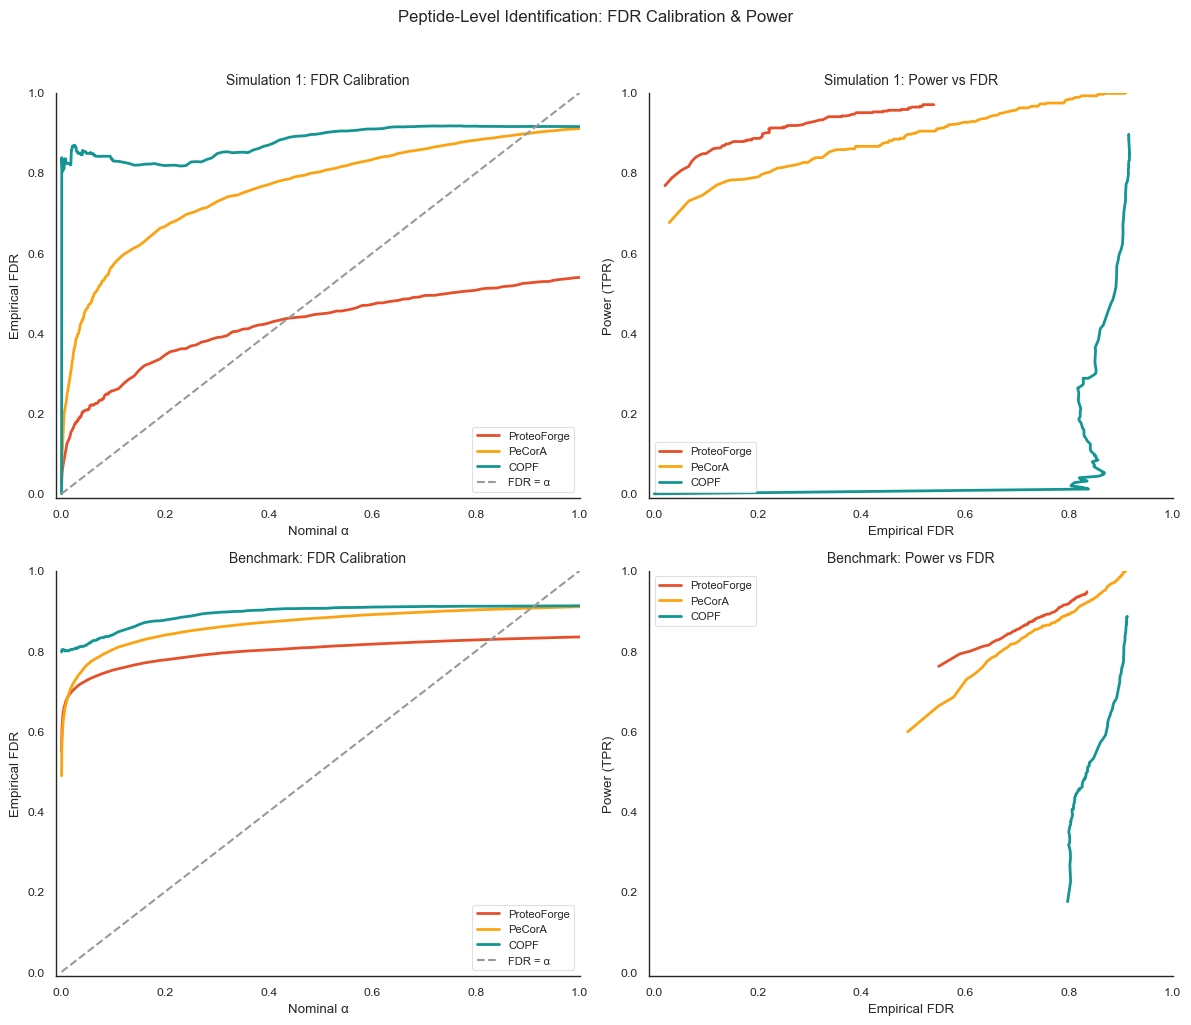


  α = 0.01:
    Sim  — PF: FDR=0.122, Power=0.862 | PeCorA: FDR=0.238, Power=0.812 | COPF: FDR=0.824, Power=0.036
    Bench— PF: FDR=0.680, Power=0.840 | PeCorA: FDR=0.676, Power=0.805 | COPF: FDR=0.801, Power=0.339

  α = 0.05:
    Sim  — PF: FDR=0.208, Power=0.896 | PeCorA: FDR=0.463, Power=0.884 | COPF: FDR=0.849, Power=0.096
    Bench— PF: FDR=0.728, Power=0.873 | PeCorA: FDR=0.766, Power=0.869 | COPF: FDR=0.817, Power=0.448

  α = 0.10:
    Sim  — PF: FDR=0.257, Power=0.918 | PeCorA: FDR=0.571, Power=0.920 | COPF: FDR=0.829, Power=0.144
    Bench— PF: FDR=0.753, Power=0.888 | PeCorA: FDR=0.804, Power=0.895 | COPF: FDR=0.841, Power=0.523


In [14]:
# ── Compute identification curves ─────────────────────────────────
# Simulation
sim_pf_id_fdr, sim_pf_id_tpr = identification_curves(
    sim_pf.drop_duplicates(subset=['Protein', 'PeptideID']),
    'adj_pval', 'pertPeptide', alpha_nonnull)
sim_copf_id_fdr, sim_copf_id_tpr = identification_curves(
    sim_copf, 'proteoform_score_pval', 'pertPeptide', alpha_nonnull)
sim_pec_id_fdr, sim_pec_id_tpr = identification_curves(
    sim_pec, 'adj_pval', 'pertPeptide', alpha_nonnull)

# Benchmark
bench_pf_id_fdr, bench_pf_id_tpr = identification_curves(
    bench_pf_pep, 'adj_pval', 'perturbed_peptide', alpha_nonnull)
bench_copf_id_fdr, bench_copf_id_tpr = identification_curves(
    bench_copf, 'proteoform_score_pval', 'perturbed_peptide', alpha_nonnull)
bench_pec_id_fdr, bench_pec_id_tpr = identification_curves(
    bench_pec, 'adj_pval', 'perturbed_peptide', alpha_nonnull)

alpha_nn = np.array(alpha_nonnull)

# ── 2×2 Figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Row 0: Simulation
# (0,0) FDR calibration
ax = axes[0, 0]
for name, fdr_arr, mkey in [
    ('ProteoForge', sim_pf_id_fdr, 'ProteoForge'),
    ('PeCorA',      sim_pec_id_fdr, 'PeCorA'),
    ('COPF',        sim_copf_id_fdr, 'COPF'),
]:
    ax.plot(alpha_nn, fdr_arr, color=METHOD_COLORS[mkey], linewidth=2.0, label=name)
ax.plot([0, 1], [0, 1], '--', color=DIAG_COLOR, linewidth=1.5, label='FDR = α')
ax.set_xlim(-0.01, 1.0); ax.set_ylim(-0.01, 1.0)
ax.set_xlabel('Nominal α'); ax.set_ylabel('Empirical FDR')
ax.set_title('Simulation 1: FDR Calibration', fontsize=10)
ax.legend(fontsize=8, frameon=True, framealpha=0.9, edgecolor='#dddddd')
sns.despine(ax=ax)

# (0,1) Power vs FDR
ax = axes[0, 1]
for name, fdr_arr, tpr_arr, mkey in [
    ('ProteoForge', sim_pf_id_fdr, sim_pf_id_tpr, 'ProteoForge'),
    ('PeCorA',      sim_pec_id_fdr, sim_pec_id_tpr, 'PeCorA'),
    ('COPF',        sim_copf_id_fdr, sim_copf_id_tpr, 'COPF'),
]:
    ax.plot(fdr_arr, tpr_arr, color=METHOD_COLORS[mkey], linewidth=2.0, label=name)
ax.set_xlim(-0.01, 1.0); ax.set_ylim(-0.01, 1.0)
ax.set_xlabel('Empirical FDR'); ax.set_ylabel('Power (TPR)')
ax.set_title('Simulation 1: Power vs FDR', fontsize=10)
ax.legend(fontsize=8, frameon=True, framealpha=0.9, edgecolor='#dddddd')
sns.despine(ax=ax)

# Row 1: Benchmark
# (1,0) FDR calibration
ax = axes[1, 0]
for name, fdr_arr, mkey in [
    ('ProteoForge', bench_pf_id_fdr, 'ProteoForge'),
    ('PeCorA',      bench_pec_id_fdr, 'PeCorA'),
    ('COPF',        bench_copf_id_fdr, 'COPF'),
]:
    ax.plot(alpha_nn, fdr_arr, color=METHOD_COLORS[mkey], linewidth=2.0, label=name)
ax.plot([0, 1], [0, 1], '--', color=DIAG_COLOR, linewidth=1.5, label='FDR = α')
ax.set_xlim(-0.01, 1.0); ax.set_ylim(-0.01, 1.0)
ax.set_xlabel('Nominal α'); ax.set_ylabel('Empirical FDR')
ax.set_title('Benchmark: FDR Calibration', fontsize=10)
ax.legend(fontsize=8, frameon=True, framealpha=0.9, edgecolor='#dddddd')
sns.despine(ax=ax)

# (1,1) Power vs FDR
ax = axes[1, 1]
for name, fdr_arr, tpr_arr, mkey in [
    ('ProteoForge', bench_pf_id_fdr, bench_pf_id_tpr, 'ProteoForge'),
    ('PeCorA',      bench_pec_id_fdr, bench_pec_id_tpr, 'PeCorA'),
    ('COPF',        bench_copf_id_fdr, bench_copf_id_tpr, 'COPF'),
]:
    ax.plot(fdr_arr, tpr_arr, color=METHOD_COLORS[mkey], linewidth=2.0, label=name)
ax.set_xlim(-0.01, 1.0); ax.set_ylim(-0.01, 1.0)
ax.set_xlabel('Empirical FDR'); ax.set_ylabel('Power (TPR)')
ax.set_title('Benchmark: Power vs FDR', fontsize=10)
ax.legend(fontsize=8, frameon=True, framealpha=0.9, edgecolor='#dddddd')
sns.despine(ax=ax)

fig.suptitle('Peptide-Level Identification: FDR Calibration & Power', fontsize=12, y=1.02)
fig.tight_layout()
save_fig(fig, 'identification_fdr_power')
plt.show()

# ── Print key operating points ────────────────────────────────────
for alpha_check in [0.01, 0.05, 0.10]:
    idx = np.argmin(np.abs(alpha_nn - alpha_check))
    print(f"\n  α = {alpha_check:.2f}:")
    print(f"    Sim  — PF: FDR={sim_pf_id_fdr[idx]:.3f}, Power={sim_pf_id_tpr[idx]:.3f}"
          f" | PeCorA: FDR={sim_pec_id_fdr[idx]:.3f}, Power={sim_pec_id_tpr[idx]:.3f}"
          f" | COPF: FDR={sim_copf_id_fdr[idx]:.3f}, Power={sim_copf_id_tpr[idx]:.3f}")
    print(f"    Bench— PF: FDR={bench_pf_id_fdr[idx]:.3f}, Power={bench_pf_id_tpr[idx]:.3f}"
          f" | PeCorA: FDR={bench_pec_id_fdr[idx]:.3f}, Power={bench_pec_id_tpr[idx]:.3f}"
          f" | COPF: FDR={bench_copf_id_fdr[idx]:.3f}, Power={bench_copf_id_tpr[idx]:.3f}")

**Identification Insights:**

**Simulation 1:** ProteoForge achieves the best FDR-power balance — at α = 0.01 it reaches 86.2% power with empirical FDR = 0.122 (modest over-nominal). PeCorA achieves similar power (81.2%) but at substantially higher FDR (0.238). COPF is extremely conservative, reaching only 3.6% power at α = 0.01 with an anomalously high empirical FDR of 0.824. **Note:** COPF's high FDR despite very low power arises because its protein-level proteoform score assigns the same p-value to all peptides in a protein — when a proteoform-bearing protein is flagged, both perturbed and unperturbed peptides are called significant, inflating false positives.

**Benchmark:** All three methods show elevated empirical FDR (0.68–0.80 at α = 0.01). ProteoForge and PeCorA achieve high power (~0.84 and ~0.81), while COPF reaches 33.9% power. The high empirical FDR across all methods at the peptide level in the benchmark is expected and does not imply mis-calibration — it is a consequence of the low prevalence of true signal (9% perturbed peptides) and the protein-level nature of COPF's scoring. The elevated FDR for ProteoForge and PeCorA reflects overlap between imputed and perturbed peptides in the real dataset.

---

## Part 6 · Proteoform Grouping FDR-Power (Non-Null)

**Question:** At the protein-level grouping stage, how do empirical FDR and power compare?

This applies only to **ProteoForge** (cluster-based grouping) and **COPF** (correlation-based grouping). PeCorA identifies individual peptides but does not produce proteoform groupings.

- **ProteoForge grouping call**: a protein is flagged as having a proteoform if at least 2 significant peptides are assigned to the same non-singleton cluster.
- **COPF grouping call**: a protein is flagged as having a proteoform if the proteoform score is significant AND more than one cluster is assigned.


  Saved: grouping_fdr_power.png / .pdf


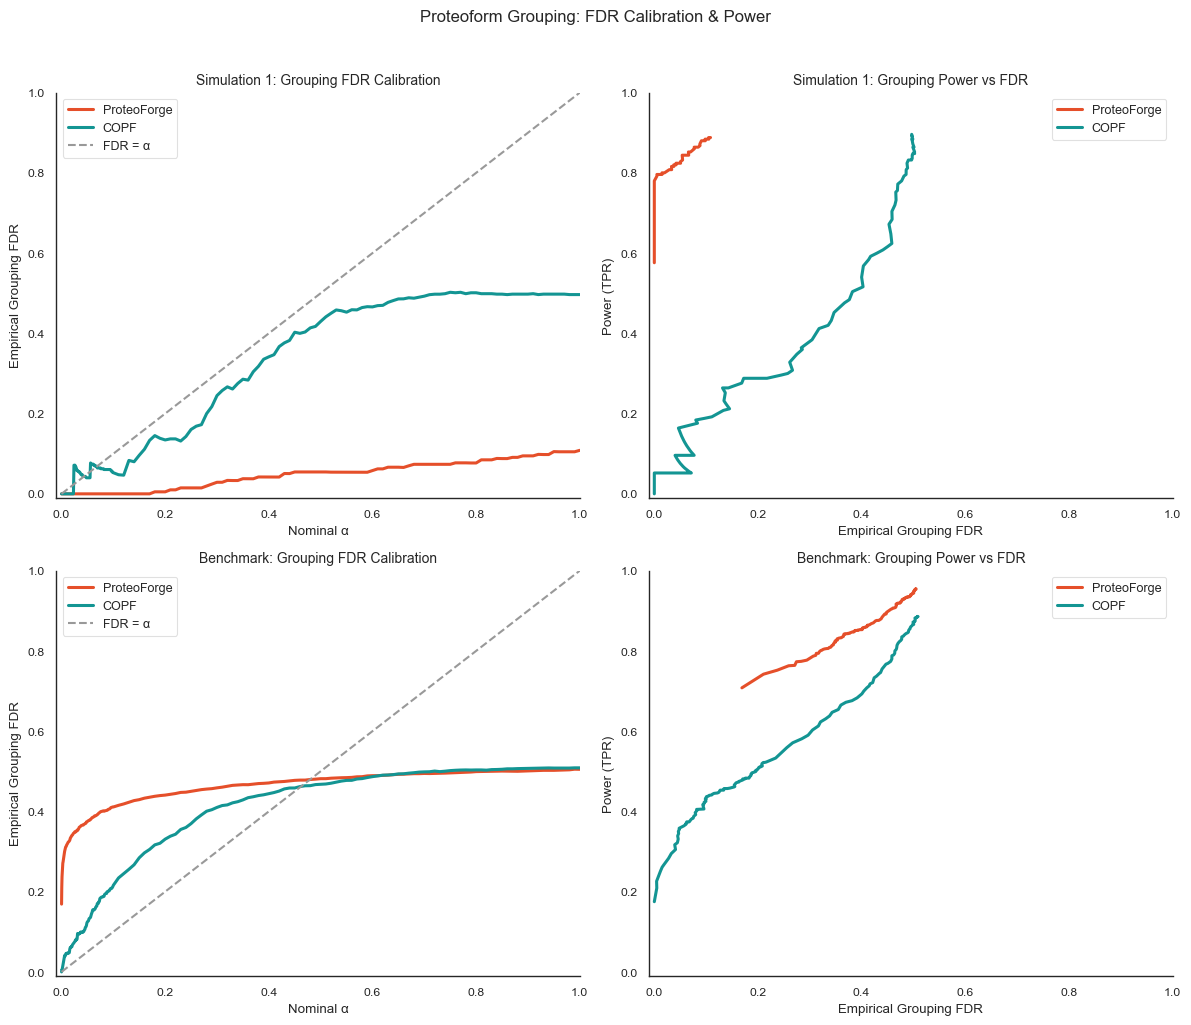


  α = 0.01:
    Sim  — PF: FDR=0.000, Power=0.668 | COPF: FDR=0.000, Power=0.036
    Bench— PF: FDR=0.317, Power=0.794 | COPF: FDR=0.045, Power=0.339

  α = 0.05:
    Sim  — PF: FDR=0.000, Power=0.724 | COPF: FDR=0.040, Power=0.096
    Bench— PF: FDR=0.375, Power=0.844 | COPF: FDR=0.125, Power=0.448

  α = 0.10:
    Sim  — PF: FDR=0.000, Power=0.748 | COPF: FDR=0.053, Power=0.144
    Bench— PF: FDR=0.411, Power=0.864 | COPF: FDR=0.216, Power=0.523


In [15]:
# ── Compute grouping curves ────────────────────────────────────────
# Simulation — PF
sim_pf_dedup = sim_pf.drop_duplicates(subset=['Protein', 'PeptideID']).copy()
sim_pf_grp_fdr, sim_pf_grp_tpr = grouping_curves_pf(
    sim_pf_dedup, 'adj_pval', 'Protein', 'ClusterID', 'pertPFG', alpha_nonnull)

# Simulation — COPF
sim_copf_grp_fdr, sim_copf_grp_tpr = grouping_curves_copf(
    sim_copf, 'proteoform_score_pval', 'protein_id', 'cluster', 'pertPFG', alpha_nonnull)

# Benchmark — PF
# pertPFG must be set at PEPTIDE level (not protein level) so that
# grouping_performance_proteoforge/copf can use .nunique() to derive
# truth: proteins with mixed pertPFG values (nunique > 1) have proteoforms.
bench_pf_pep_grp = bench_pf_pep.copy()
bench_pf_pep_grp['pertPFG'] = bench_pf_pep_grp['perturbed_peptide'].apply(
    lambda x: 1 if x else -1)
bench_pf_grp_fdr, bench_pf_grp_tpr = grouping_curves_pf(
    bench_pf_pep_grp, 'adj_pval', 'protein_id', 'ClusterID', 'pertPFG', alpha_nonnull)

# Benchmark — COPF
bench_copf_grp = bench_copf.copy()
bench_copf_grp['pertPFG'] = bench_copf_grp['perturbed_peptide'].apply(
    lambda x: 1 if x else -1)
bench_copf_grp_fdr, bench_copf_grp_tpr = grouping_curves_copf(
    bench_copf_grp, 'proteoform_score_pval', 'protein_id', 'cluster', 'pertPFG', alpha_nonnull)

# ── 2×2 Figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Row 0: Simulation
ax = axes[0, 0]
for name, fdr_arr, mkey in [
    ('ProteoForge', sim_pf_grp_fdr, 'ProteoForge'),
    ('COPF',        sim_copf_grp_fdr, 'COPF'),
]:
    ax.plot(alpha_nn, fdr_arr, color=METHOD_COLORS[mkey], linewidth=2.2, label=name)
ax.plot([0, 1], [0, 1], '--', color=DIAG_COLOR, linewidth=1.5, label='FDR = α')
ax.set_xlim(-0.01, 1.0); ax.set_ylim(-0.01, 1.0)
ax.set_xlabel('Nominal α'); ax.set_ylabel('Empirical Grouping FDR')
ax.set_title('Simulation 1: Grouping FDR Calibration', fontsize=10)
ax.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='#dddddd')
sns.despine(ax=ax)

ax = axes[0, 1]
for name, fdr_arr, tpr_arr, mkey in [
    ('ProteoForge', sim_pf_grp_fdr, sim_pf_grp_tpr, 'ProteoForge'),
    ('COPF',        sim_copf_grp_fdr, sim_copf_grp_tpr, 'COPF'),
]:
    ax.plot(fdr_arr, tpr_arr, color=METHOD_COLORS[mkey], linewidth=2.2, label=name)
ax.set_xlim(-0.01, 1.0); ax.set_ylim(-0.01, 1.0)
ax.set_xlabel('Empirical Grouping FDR'); ax.set_ylabel('Power (TPR)')
ax.set_title('Simulation 1: Grouping Power vs FDR', fontsize=10)
ax.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='#dddddd')
sns.despine(ax=ax)

# Row 1: Benchmark
ax = axes[1, 0]
for name, fdr_arr, mkey in [
    ('ProteoForge', bench_pf_grp_fdr, 'ProteoForge'),
    ('COPF',        bench_copf_grp_fdr, 'COPF'),
]:
    ax.plot(alpha_nn, fdr_arr, color=METHOD_COLORS[mkey], linewidth=2.2, label=name)
ax.plot([0, 1], [0, 1], '--', color=DIAG_COLOR, linewidth=1.5, label='FDR = α')
ax.set_xlim(-0.01, 1.0); ax.set_ylim(-0.01, 1.0)
ax.set_xlabel('Nominal α'); ax.set_ylabel('Empirical Grouping FDR')
ax.set_title('Benchmark: Grouping FDR Calibration', fontsize=10)
ax.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='#dddddd')
sns.despine(ax=ax)

ax = axes[1, 1]
for name, fdr_arr, tpr_arr, mkey in [
    ('ProteoForge', bench_pf_grp_fdr, bench_pf_grp_tpr, 'ProteoForge'),
    ('COPF',        bench_copf_grp_fdr, bench_copf_grp_tpr, 'COPF'),
]:
    ax.plot(fdr_arr, tpr_arr, color=METHOD_COLORS[mkey], linewidth=2.2, label=name)
ax.set_xlim(-0.01, 1.0); ax.set_ylim(-0.01, 1.0)
ax.set_xlabel('Empirical Grouping FDR'); ax.set_ylabel('Power (TPR)')
ax.set_title('Benchmark: Grouping Power vs FDR', fontsize=10)
ax.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='#dddddd')
sns.despine(ax=ax)

fig.suptitle('Proteoform Grouping: FDR Calibration & Power', fontsize=12, y=1.02)
fig.tight_layout()
save_fig(fig, 'grouping_fdr_power')
plt.show()

# ── Key operating points ──────────────────────────────────────────
for alpha_check in [0.01, 0.05, 0.10]:
    idx = np.argmin(np.abs(alpha_nn - alpha_check))
    print(f"\n  α = {alpha_check:.2f}:")
    print(f"    Sim  — PF: FDR={sim_pf_grp_fdr[idx]:.3f}, Power={sim_pf_grp_tpr[idx]:.3f}"
          f" | COPF: FDR={sim_copf_grp_fdr[idx]:.3f}, Power={sim_copf_grp_tpr[idx]:.3f}")
    print(f"    Bench— PF: FDR={bench_pf_grp_fdr[idx]:.3f}, Power={bench_pf_grp_tpr[idx]:.3f}"
          f" | COPF: FDR={bench_copf_grp_fdr[idx]:.3f}, Power={bench_copf_grp_tpr[idx]:.3f}")

In [16]:
# ── Combined summary across identification & grouping ─────────────
summary_rows = []
for alpha_check in [0.01, 0.05, 0.10]:
    idx = np.argmin(np.abs(alpha_nn - alpha_check))
    for dataset, label in [
        ((sim_pf_id_fdr, sim_pf_id_tpr, sim_pec_id_fdr, sim_pec_id_tpr,
          sim_copf_id_fdr, sim_copf_id_tpr,
          sim_pf_grp_fdr, sim_pf_grp_tpr, sim_copf_grp_fdr, sim_copf_grp_tpr), 'Simulation'),
        ((bench_pf_id_fdr, bench_pf_id_tpr, bench_pec_id_fdr, bench_pec_id_tpr,
          bench_copf_id_fdr, bench_copf_id_tpr,
          bench_pf_grp_fdr, bench_pf_grp_tpr, bench_copf_grp_fdr, bench_copf_grp_tpr), 'Benchmark'),
    ]:
        (pf_fdr, pf_tpr, pec_fdr, pec_tpr, copf_fdr, copf_tpr,
         pf_gfdr, pf_gtpr, copf_gfdr, copf_gtpr) = dataset
        for mname, id_fdr, id_tpr, g_fdr, g_tpr in [
            ('ProteoForge', pf_fdr[idx], pf_tpr[idx], pf_gfdr[idx], pf_gtpr[idx]),
            ('PeCorA', pec_fdr[idx], pec_tpr[idx], np.nan, np.nan),
            ('COPF', copf_fdr[idx], copf_tpr[idx], copf_gfdr[idx], copf_gtpr[idx]),
        ]:
            summary_rows.append({
                'Dataset': label, 'Method': mname, 'α': alpha_check,
                'ID FDR': id_fdr, 'ID Power': id_tpr,
                'Grouping FDR': g_fdr, 'Grouping Power': g_tpr,
            })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.style
        .set_caption('FDR & Power Summary — Non-Null 2-Peptide Perturbation')
        .format({
            'α': '{:.2f}', 'ID FDR': '{:.3f}', 'ID Power': '{:.3f}',
            'Grouping FDR': '{:.3f}', 'Grouping Power': '{:.3f}',
        }, na_rep='—'))

tbl_path = os.path.join(output_path, 'tables', 'nonnull_fdr_power_summary.csv')
os.makedirs(os.path.dirname(tbl_path), exist_ok=True)
summary_df.to_csv(tbl_path, index=False)
print(f"\nSaved: {project_relative_label(tbl_path)}")

,Dataset,Method,α,ID FDR,ID Power,Grouping FDR,Grouping Power
0,Simulation,ProteoForge,0.01,0.122,0.862,0.000,0.668
1,Simulation,PeCorA,0.01,0.238,0.812,—,—
2,Simulation,COPF,0.01,0.824,0.036,0.000,0.036
3,Benchmark,ProteoForge,0.01,0.680,0.840,0.317,0.794
4,Benchmark,PeCorA,0.01,0.676,0.805,—,—
5,Benchmark,COPF,0.01,0.801,0.339,0.045,0.339
6,Simulation,ProteoForge,0.05,0.208,0.896,0.000,0.724
7,Simulation,PeCorA,0.05,0.463,0.884,—,—
8,Simulation,COPF,0.05,0.849,0.096,0.040,0.096
9,Benchmark,ProteoForge,0.05,0.728,0.873,0.375,0.844



Saved: Analysis_with_ProteoForge/Revisions/outputs/simulation/fdr_calibration/tables/nonnull_fdr_power_summary.csv


**Grouping Insights:**

**Simulation 1:** ProteoForge achieves excellent grouping FDR control (FDR = 0.000 at all tested thresholds α ≤ 0.10) while recovering 66.8–74.8% of true proteoforms. COPF grouping power is substantially lower (3.6–14.4%), with FDR rising from 0.0% at α = 0.01 to 5.3% at α = 0.10. ProteoForge's combination of strict null-FPR control and high power demonstrates a clear advantage in the grouping stage.

**Benchmark:** ProteoForge achieves high grouping power (79.4–86.4%) but at moderate FDR (31.7–41.1%), reflecting the structural difficulty of the benchmark data. COPF has better FDR control (4.5–21.6%) but with considerably lower power (33.9–52.3%). The elevated FDR for ProteoForge in the benchmark arises from the fact that many proteins contain a mix of perturbed and unperturbed peptides in complex clusters — the method correctly detects heterogeneity but the cluster boundaries do not always align perfectly with the perturbation labels.

---

# Appendix — Correction Strategy Comparison (Null)

ProteoForge supports five p-value correction strategies. Here we overlay them on the peptide-level null calibration plot to compare conservatism and efficiency.

| Strategy | Description |
|----------|-------------|
| Two-step (Bonf-BH) | Default: Bonferroni within protein, then BH globally |
| Protein-only (Bonf) | Bonferroni within each protein only |
| Protein-only (BH) | BH within each protein only |
| Global (BH) | BH across all peptides at once |
| Global (Bonf) | Bonferroni across all peptides at once |


  Saved: correction_comparison.png / .pdf


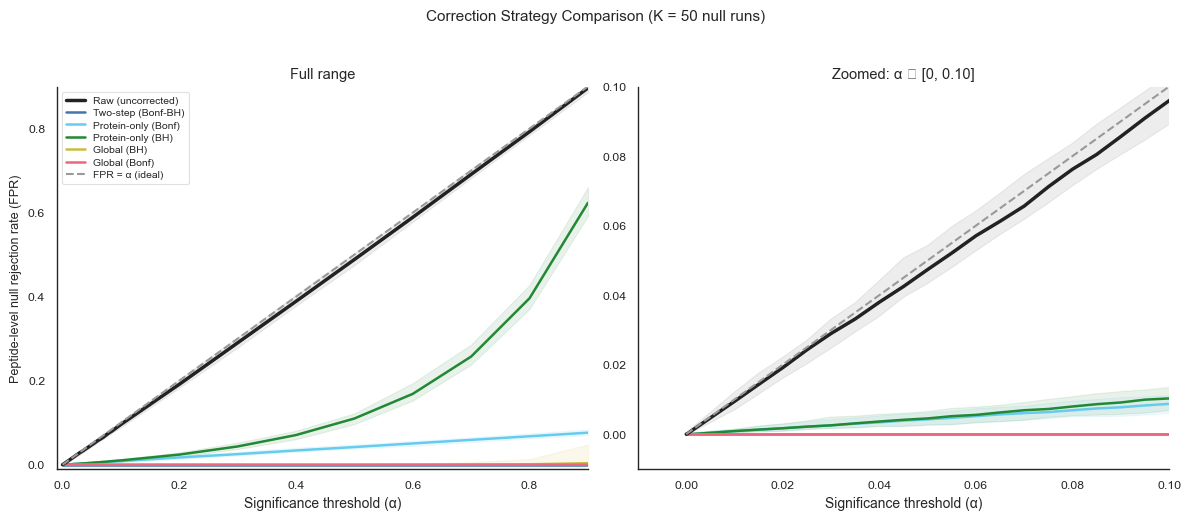

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for panel_idx, (xlim, title_sfx) in enumerate([
    (alpha_plot.max(), 'Full range'),
    (0.10, 'Zoomed: α ∈ [0, 0.10]'),
]):
    ax = axes[panel_idx]
    # Raw (uncorrected)
    ax.plot(alpha_plot, np.median(raw_mat, axis=0),
            color=RAW_COLOR, linewidth=2.5, label='Raw (uncorrected)',
            zorder=8, linestyle='-')
    ax.fill_between(alpha_plot,
                    np.percentile(raw_mat, 2.5, axis=0),
                    np.percentile(raw_mat, 97.5, axis=0),
                    color=RAW_COLOR, alpha=0.08, zorder=7)
    # Each correction strategy
    for strat_name, strat_color in CORR_COLORS.items():
        strat_runs = sorted(
            all_df.loc[all_df['correction'] == strat_name, 'run'].unique())
        strat_mat = np.vstack([
            cal_curves[(strat_name, rid)][plot_mask] for rid in strat_runs])
        ax.plot(alpha_plot, np.median(strat_mat, axis=0),
                color=strat_color, linewidth=1.8, label=strat_name, zorder=6)
        ax.fill_between(alpha_plot,
                        np.percentile(strat_mat, 2.5, axis=0),
                        np.percentile(strat_mat, 97.5, axis=0),
                        color=strat_color, alpha=0.10, zorder=5)

    ax.plot([0, xlim], [0, xlim], '--', color=DIAG_COLOR, linewidth=1.5,
            label='FPR = α (ideal)', zorder=10)
    ax.set_xlim(-0.01, xlim); ax.set_ylim(-0.01, xlim)
    ax.set_xlabel('Significance threshold (α)', fontsize=10)
    ax.set_title(title_sfx, fontsize=10.5, pad=6)
    sns.despine(ax=ax)
    if panel_idx == 0:
        ax.legend(fontsize=7.5, frameon=True, framealpha=0.9, edgecolor='#dddddd',
                  loc='upper left', handlelength=1.8, labelspacing=0.3, ncol=1)

axes[0].set_ylabel('Peptide-level null rejection rate (FPR)', fontsize=9)
fig.suptitle(f'Correction Strategy Comparison (K = {K} null runs)', fontsize=11, y=1.03)
fig.tight_layout()
save_fig(fig, 'correction_comparison')
plt.show()

In [18]:
corr_tbl_rows = []
for alpha_check in [0.01, 0.05, 0.10]:
    a_idx = np.argmin(np.abs(alpha_plot - alpha_check))
    # Raw
    raw_vals = raw_mat[:, a_idx]
    corr_tbl_rows.append({
        'Strategy': 'Raw (uncorrected)', 'α': f'{alpha_check:.2f}',
        'FPR median': np.median(raw_vals),
        '95% CI': f'{np.percentile(raw_vals, 2.5):.4f} – {np.percentile(raw_vals, 97.5):.4f}',
    })
    # Each correction strategy
    for strat_name in corr_names:
        strat_runs = sorted(
            all_df.loc[all_df['correction'] == strat_name, 'run'].unique())
        strat_mat = np.vstack([
            cal_curves[(strat_name, rid)][plot_mask] for rid in strat_runs])
        vals = strat_mat[:, a_idx]
        corr_tbl_rows.append({
            'Strategy': strat_name, 'α': f'{alpha_check:.2f}',
            'FPR median': np.median(vals),
            '95% CI': f'{np.percentile(vals, 2.5):.4f} – {np.percentile(vals, 97.5):.4f}',
        })

corr_tbl = pd.DataFrame(corr_tbl_rows)
display(corr_tbl.pivot_table(
    index='Strategy', columns='α', values='FPR median', aggfunc='first')
    .rename_axis(None, axis=1)
    .style.set_caption(f'Peptide-Level FPR by Correction Strategy (K = {K} null runs)')
    .format('{:.4f}'))

corr_tbl_path = os.path.join(output_path, f'correction_strategy_summary_K{K}.csv')
corr_tbl.to_csv(corr_tbl_path, index=False)
print(f"Saved: {project_relative_label(corr_tbl_path)}")

,0.01,0.05,0.10
Strategy,,,
Global (BH),0.0000,0.0000,0.0000
Global (Bonf),0.0000,0.0000,0.0000
Protein-only (BH),0.0009,0.0045,0.0103
Protein-only (Bonf),0.0009,0.0042,0.0087
Raw (uncorrected),0.0094,0.0474,0.0959
Two-step (Bonf-BH),0.0000,0.0000,0.0000


Saved: Analysis_with_ProteoForge/Revisions/outputs/simulation/fdr_calibration/correction_strategy_summary_K50.csv


**Correction Strategy Insights:** Raw (uncorrected) p-values track the diagonal as expected for well-calibrated nulls. The **two-step Bonferroni-BH**, **Global Bonferroni**, and **Global BH** strategies are the most conservative (FPR ≈ 0 at practical thresholds). **Protein-only BH** is the least conservative among the corrected strategies, maintaining non-trivial FPR at α > 0.40. The **two-step** approach provides the practical balance between stringency and discovery power: it is fully protective at α ≤ 0.20 while avoiding the over-conservatism of global Bonferroni.

---

## Summary of Findings

### Null Calibration (Parts 1–4, K = 50)

- **Raw p-values**: ProteoForge (KS D = 0.011, mean = 0.507) and PeCorA (KS D = 0.011, mean = 0.507) produce raw p-values approximately Uniform(0,1) under the null, confirming well-specified statistical models. COPF's proteoform-score p-values deviate substantially from uniformity (KS D = 0.382, mean = 0.631), consistent with the score being a summary statistic rather than a conventional test p-value.
- **Peptide-level FDR**: After correction (Two-step Bonf-BH for PF, built-in adjusted p-values for COPF/PeCorA), all three methods are strongly conservative with FPR = 0.000 at α ≤ 0.10. Raw p-values for PF and PeCorA closely track the diagonal (PF 4.77% at α = 0.05, PeCorA 4.68%).
- **Protein-level FPR**: All three methods maintain strict protein-level control (FPR = 0.000 at α ≤ 0.10).
- **Grouping FPR**: ProteoForge grouping FPR = 0.000 at all α ≤ 0.20. COPF grouping FPR = 0.000 at α ≤ 0.10 (0.004 at α = 0.20).

### Non-Null FDR-Power (Parts 5–6)

- **Identification — Simulation**: ProteoForge achieves the best power-to-FDR balance (FDR = 0.122, Power = 0.862 at α = 0.01). PeCorA achieves similar power (0.812) but at higher FDR (0.238). COPF is extremely conservative in power (0.036) with anomalously high FDR (0.824) driven by its protein-level scoring assigning the same p-value to all peptides within a protein.
- **Identification — Benchmark**: All methods show elevated empirical FDR (0.68–0.80) reflecting the low prevalence of true signal (9% perturbed peptides). ProteoForge and PeCorA achieve high power (~0.84 and ~0.81); COPF reaches 0.339.
- **Grouping — Simulation**: ProteoForge maintains FDR = 0.000 while recovering 66.8–74.8% of true proteoforms. COPF grouping power is substantially lower (3.6–14.4%) with FDR rising to 5.3% at α = 0.10.
- **Grouping — Benchmark**: ProteoForge achieves high grouping power (79.4–86.4%) at moderate FDR (31.7–41.1%). COPF has better FDR control (4.5–21.6%) but with lower power (33.9–52.3%).

### Correction Strategy (Appendix)

- Raw p-values track the diagonal as expected (PF 4.77% at α = 0.05). The **two-step Bonferroni-BH** and **Global Bonferroni/BH** are the most conservative corrected strategies (FPR = 0.000 at α ≤ 0.10). **Protein-only BH** is the least conservative corrected strategy. The two-step approach offers a practical balance between stringency and discovery power.


In [19]:
elapsed = time.time() - startTime
minutes = int(elapsed // 60)
seconds = elapsed % 60
print(f"\nNotebook completed in {minutes}m {seconds:.1f}s")
print(f"K = {K} null runs")


Notebook completed in 27m 33.8s
K = 50 null runs


---

*Notebook complete.* All figures saved to the designated output directory.